# Random Forest

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [11]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

In [12]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred=rf.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[83, 16],
       [20, 35]])

In [15]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [16]:
accuracy = (TP+TN)/(TP+TN+FP+FN)
error_rate = (FP+FN)/(TP+TN+FP+FN) 
sensitivity = TP/(TP+FN)
specificity = TN/(TN+FP)
precision=TP/(TP+FP)

print('accuracy =',accuracy)
print('error rate =',error_rate)
print('sensitivity =',sensitivity)
print('specificity =',specificity)
print('precision =',precision)

accuracy = 0.7662337662337663
error rate = 0.23376623376623376
sensitivity = 0.6363636363636364
specificity = 0.8383838383838383
precision = 0.6862745098039216


In [17]:
# Practice Que
# The objective is to predict hotel booking status using a Decision Tree classifier. The dataset undergoes preprocessing one-hot encoding for categorical features.
# The data is split into training and testing sets (80%-20%). The model is optimized by trying different values of max_depth (1-20), selecting the depth that achieves
# the highest accuracy. The final model is trained with the best max_depth, and its performance is evaluated using accuracy score, classification report, and confusion
# matrix. 

# "Hotel Reservations.csv" 
# for problem 3 and problem 4 Prdict for problem 3 and 4 
# 'no_of adults': 2, 
# 'no_of children: 1, 
# 'no_of_weekend_nights': 2, 
# 'no_of week nights: 3, 
# 'type_of_meal_plan: 'Meal Plan 1', 
# 'required_car_parking_space: 0, 
# 'room_type_reserved: 'Room_Type 1', 
# 'lead_time': 120, 
# "arrival_year: 2023 
# 'arrival_month': 8 
# 'arrival_date: 15, 
# 'market_segment_type: 'Online', 
# 'repeated_guest: 0,
#  'no_of previous_cancellations: 0, 
# no_of_previous_bookings_not_canceled: 1, 
# 'avg_price_per_room: 110.5, 
# 'no_of special_requests: 1

In [30]:
df= pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [31]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [32]:
df.drop(columns=['Booking_ID'],inplace=True)

In [33]:
df= pd.get_dummies(data=df, drop_first=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,True,False,True
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,True,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,True,False
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,True,False
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,True,False


In [34]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'booking_status_Not_Canceled'],
      dtype='object')

In [35]:
y=df['booking_status_Not_Canceled']
x=df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online']]

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(29020, 27)
(7255, 27)
(29020,)
(7255,)


In [45]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix,mean_squared_error,accuracy_score
from sklearn.metrics import 
import matplotlib.pyplot as plt
accu = []
MSE=[]
depth=[]
for i in range(1,21):
    model= DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=42)
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    cm = confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy = (TP+TN)/(TP+TN+FP+FN)
    mse = mean_squared_error(y_test, y_pred)
    accu.append(accuracy)
    depth.append(i)
    MSE.append(mse)
max_index = accu.index(max(accu))+1
print(max_index)

model= DecisionTreeClassifier(criterion='entropy', max_depth=max_index, random_state=42)
model.fit(x_train, y_train)
pred=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
print('Pred = ',pred)

plt.plot(depth,MSE,'*-r')
plt.show()

[np.float64(0.7651274982770503), np.float64(0.7651274982770503), np.float64(0.7830461750516885), np.float64(0.8137835975189525), np.float64(0.830737422467264), np.float64(0.833907649896623), np.float64(0.850999310820124), np.float64(0.8578911095796002), np.float64(0.867539627842867), np.float64(0.868090971743625), np.float64(0.8745692625775328), np.float64(0.8796691936595451), np.float64(0.8781529979324604), np.float64(0.882012405237767), np.float64(0.8784286698828394), np.float64(0.878566505858029), np.float64(0.8773259820813232), np.float64(0.8773259820813232), np.float64(0.8766368022053757), np.float64(0.8760854583046175)]
14


1
[False]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


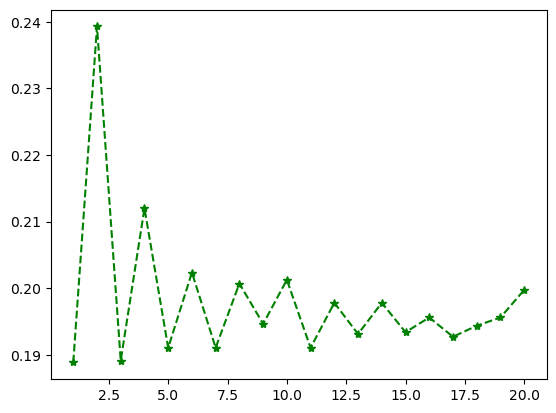

In [63]:
# same for KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error,confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
accu=[]
MSE=[]
neigh=[]
for i in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    a=accuracy_score(y_test,y_pred)
    accu.append(a)
    neigh.append(i)
    MSE.append(mean_squared_error(y_test, y_pred))
index=accu.index(max(accu))+1
print(index)

nn= KNeighborsClassifier(n_neighbors=index)
model = nn.fit(x_train, y_train)
pred= model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
print(pred)

plt.plot(neigh,MSE,'*--g')
plt.show()

50
Pred=  [ True]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


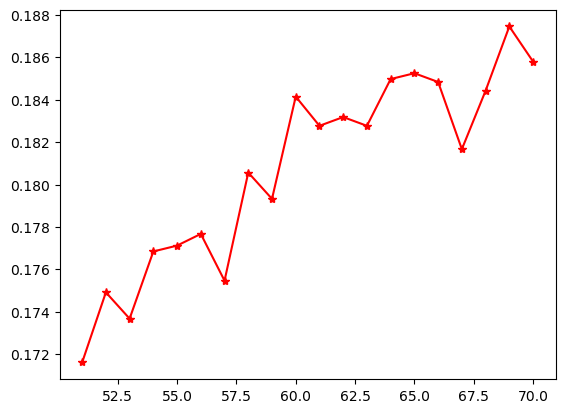

In [62]:
# same for Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,mean_squared_error,confusion_matrix
import matplotlib.pyplot as plt

n=range(51,71)
min=[]
mse=[]

for i in n:
    rf=RandomForestClassifier(n_estimators=i,max_depth=5,random_state=42)
    model=rf.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    MSE=mean_squared_error(y_pred,y_test)
    mse.append(MSE)
    accuracy=accuracy_score(y_test,y_pred)
    min.append(accuracy)    
index=min.index(max(min))+50
print(index)

rf=RandomForestClassifier(n_estimators=n1,max_depth=5,random_state=42)
model=rf.fit(x_train,y_train)
pred = rf.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
print('Pred = ',pred)

plt.plot(n,mse,'*-r')
plt.show()